In [35]:
import numpy as np

class LogisticRegressor:
    def __init__(self, lr=0.01, tol=1e-4, max_iter=1000):
        self.lr = lr
        self.tol = tol
        self.max_iter = max_iter
        self.w = None
        self.b = 0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def cost(self, y, y_pred):
        m = y.shape[0]
        epsilon = 1e-8 
        return -1/m * np.sum(
            y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon)
        )

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        m, n = X.shape  
        self.w = np.random.randn(n, 1)
        self.b = 0
        y = y.reshape(m, 1)

        for i in range(self.max_iter):
            z = X @ self.w + self.b
            y_pred = self.sigmoid(z)

            dw = (1/m) * (X.T @ (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            if np.linalg.norm(dw) < self.tol and abs(db) < self.tol:
                break

    def predict(self, X):
        X = np.array(X)
        z = X @ self.w + self.b
        y_pred = self.sigmoid(z)
        return (y_pred >= 0.5).astype(int)

    def score(self, X, y_true):
        y_pred = self.predict(X)
        return np.mean(y_pred.flatten() == y_true)


In [36]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"data/heart_diceases.csv")
df.head(5)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [37]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


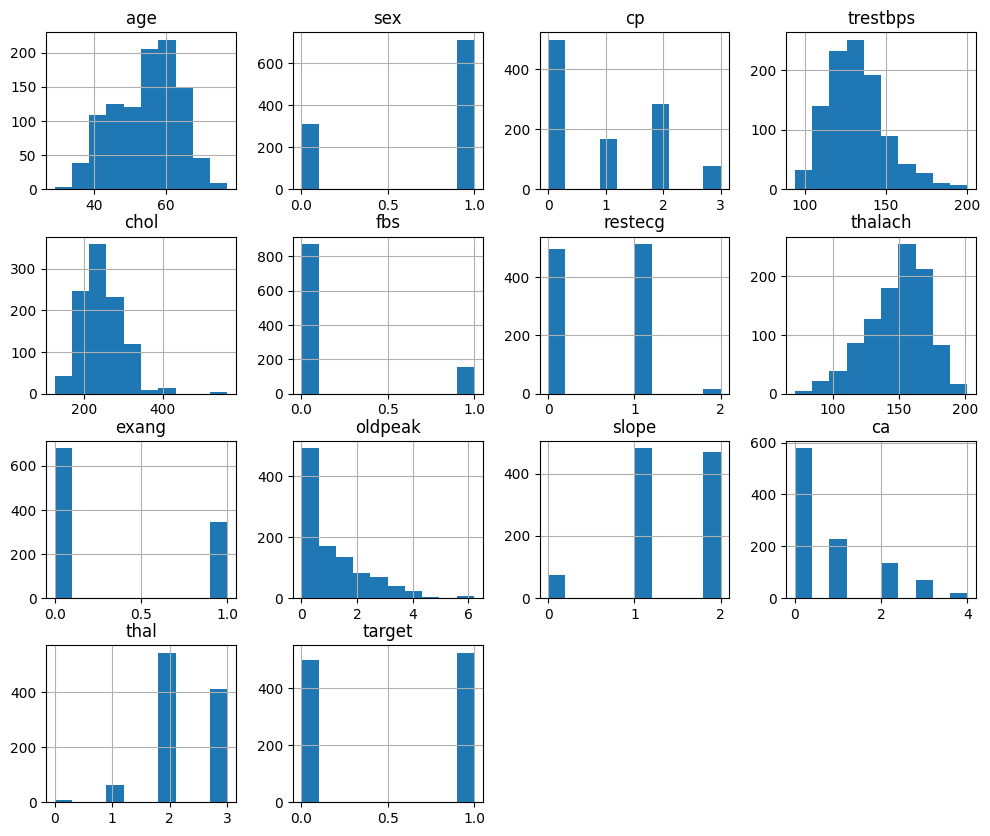

In [38]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 10))
plt.show()

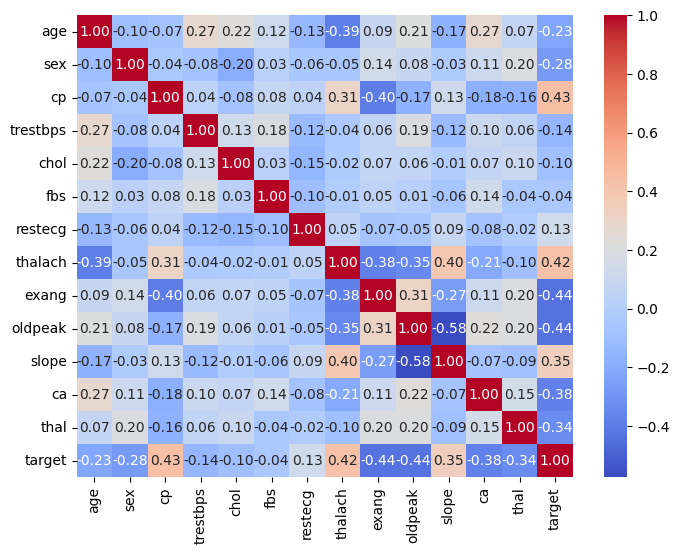

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()


In [40]:
# One-hot encode categorical variables
df = pd.get_dummies(df, columns=["cp", "thal", "slope"], drop_first=True).astype(int)
df.head(5)

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,thal_1,thal_2,thal_3,slope_1,slope_2
0,52,1,125,212,0,1,168,0,1,2,0,0,0,0,0,0,1,0,1
1,53,1,140,203,1,0,155,1,3,0,0,0,0,0,0,0,1,0,0
2,70,1,145,174,0,1,125,1,2,0,0,0,0,0,0,0,1,0,0
3,61,1,148,203,0,1,161,0,0,1,0,0,0,0,0,0,1,0,1
4,62,0,138,294,1,1,106,0,1,3,0,0,0,0,0,1,0,1,0


In [41]:
X = df.drop(columns=["target"])
y = df["target"]

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, shuffle=True)

X_test.shape, y_test.shape, X_train.shape, y_train.shape

((205, 18), (205,), (820, 18), (820,))

In [42]:
std_scaler_mod = StandardScaler()
X_train_scaled = std_scaler_mod.fit_transform(X_train)
X_test_scaled = std_scaler_mod.transform(X_test)

In [43]:
log_reg_mod = LogisticRegressor(lr=0.1, tol=1e-4, max_iter=1000)
log_reg_mod.fit(X_train_scaled, y_train)
y_test_pred = log_reg_mod.predict(X_test_scaled)
log_reg_mod.score(X_test_scaled, y_test)

np.float64(0.8292682926829268)

In [44]:
y_test = np.array(y_test)
cost = log_reg_mod.cost(y_test.T, y_test_pred.T)

cost, log_reg_mod.w, log_reg_mod.b

(np.float64(3.1449942650650384),
 array([[-0.01787089],
        [-0.80441047],
        [-0.26594326],
        [-0.28416937],
        [ 0.04092258],
        [ 0.13439671],
        [ 0.37405277],
        [-0.31895279],
        [-0.5138956 ],
        [-1.05991615],
        [ 0.33887604],
        [ 0.87351202],
        [ 0.5386649 ],
        [ 0.27021865],
        [ 0.51559747],
        [-0.16876139],
        [-0.02805851],
        [ 0.57939613]]),
 np.float64(-0.10882415591119488))

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, confusion_matrix

lod_reg = LogisticRegression(
    penalty='l2',
    tol=1e-4,
    random_state=21,
    solver='lbfgs',
    max_iter=1000
    )

lod_reg.fit(X_train_scaled, y_train)
lod_reg.predict(X_test_scaled)

print(lod_reg.coef_)
print(lod_reg.intercept_)

log_loss = log_loss(y_test, y_test_pred)
print(log_loss)

conf_matrix = confusion_matrix(y_test, y_test_pred)
print(conf_matrix)

[[-0.02261224 -0.78598206 -0.24905008 -0.26665684  0.0403688   0.14254616
   0.3636221  -0.31773645 -0.58786248 -1.01185107  0.30524122  0.83300349
   0.51504287  0.30291843  0.63425539 -0.04844106 -0.36582648  0.19996384]]
[-0.10076715]
6.153794481068783
[[83 19]
 [16 87]]


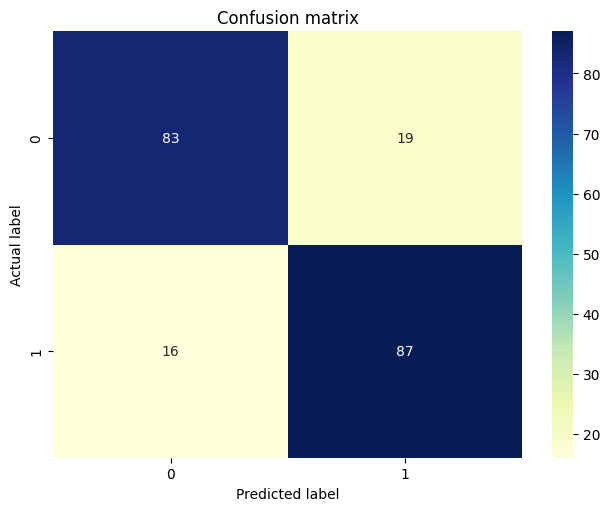

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names = [0, 1] # name of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap='YlGnBu', fmt='g')
ax.xaxis.set_label_position('bottom')
plt.tight_layout()
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

plt.show()